In [90]:
import numpy as np 
import faiss
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs
from src.utils import append_or_create_csv

In [91]:
# Loading the GIST dataset
db = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_base.fvecs'))
qr = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_query.fvecs'))


Reading File - /data/cpanourg/2-hdvc/data/gist/gist_base.fvecs:(1000000, 960)
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_query.fvecs:(1000, 960)


In [92]:
dataset_name = 'GIST'
sampling_method = 'random'  # 'random'
train_size_ratio = 0.1  # Ratio of the database to use for training if using sampling
nb = db.shape[0]  # Number of database vectors
nq = qr.shape[0]  # Number of query vectors
k = 100 # Number of nearest neighbors to search for
dim = db.shape[1]  # Dimensionality of the vectors

nbits = 8 # 2^nbits is the number of centroids for each subquantizer
n_subquantizers = 96   # Number of subquantizers for the PQ

## Search

In [7]:

start = time.time()
# Step 2: Initialize the product quantizer
pq = faiss.IndexPQ(dim, n_subquantizers, nbits)

# nlist = 100  # Number of Voronoi cells (clusters)
# quantizer = faiss.IndexFlatL2(dim)  # the other index
# pq = faiss.IndexIVFPQ(quantizer, dim, nlist,  n_subquantizers, nbits)

# Step 3: Train the PQ on the database (training data is typically a random sample of the DB)
# If you have a separate training set, you should use that instead of the full database.
if sampling_method == 'random':
    num_samples = min(int(train_size_ratio * nb), db.shape[0])  # Number of samples for training
    training_data = db[np.random.choice(db.shape[0], num_samples, replace=False)]
    print(f"Training PQ on {num_samples} random samples from the database.")

# Perform PQ training
pq.train(training_data)

# Step 4: Add the database vectors to the PQ index
pq.add(db)
end = time.time()
pq_train_add_time = np.round(end - start, 2)
print(f"Time to train and add to PQ index: {pq_train_add_time} seconds")
print("is_trained:", pq.is_trained)


start = time.time()
# Step 7: Compute approximate PQ distances
D_pq, I_pq = pq.search(qr, k)  # Approximate distances (PQ) to all DB vectors
end = time.time()   
pq_dist_time = np.round(end - start, 2)
print(f"Time to compute PQ distances: {pq_dist_time} seconds")



Training PQ on 100000 random samples from the database.
Time to train and add to PQ index: 4.08 seconds
is_trained: True
Time to compute PQ distances: 0.27 seconds


In [8]:
# Copy the codes into a NumPy array
codes_array = faiss.vector_to_array(pq.codes)  # returns a new numpy.ndarray
N = pq.ntotal        # total number of vectors in the index
code_size = pq.code_size  # bytes per vector code (product of subquantizers * bits/8, rounded up):contentReference[oaicite:6]{index=6}

codes_matrix = codes_array.reshape(N, code_size)
print(codes_matrix.shape)  # should be (N, code_size)
codes_matrix

(1000000, 8)


array([[109, 109, 169, ...,  27, 149,  42],
       [165, 140,  31, ...,  28, 130, 205],
       [206, 248, 133, ...,  73, 110,   0],
       ...,
       [229,  41, 120, ..., 246, 219, 143],
       [ 66, 124,  78, ...,  55,  55,  96],
       [129, 115, 185, ..., 113, 197, 123]], dtype=uint8)

In [9]:

start = time.time()
# Step 5: Calculate exact Euclidean distances using the flat index
index_flat = faiss.IndexFlatL2(dim)  # Exact L2 index
index_flat.add(db)
end = time.time()

l2_add_time = np.round(end - start, 2)
print(f"Time to add to Flat index: {l2_add_time} seconds")

start = time.time()
# Step 6: Compute the distances (all distances between query and database)
D_exact, I_exact = index_flat.search(qr, k)  # Exact distances (Euclidean) to all DB vectors
end = time.time()

l2_dist_time = np.round(end - start, 2)
print(f"Time to compute exact distances: {l2_dist_time} seconds")


Time to add to Flat index: 2.02 seconds
Time to compute exact distances: 2.93 seconds


In [10]:
# # Step 8: Compute relative error matrix
# # Define a small epsilon value to replace zero distances
# epsilon = 1e-6

# # Replace zeros in D_exact with epsilon
# D_exact_safe = np.where(D_exact == 0, epsilon, D_exact)

# # Now compute the relative error
# rel_error_matrix = np.abs(D_exact_safe - D_pq) / D_exact_safe

# rel_error_mean = np.mean(rel_error_matrix)
# rel_error_std = np.std(rel_error_matrix)


In [11]:
def recall_at_k(I_true, I_test, k):
    n_queries = I_true.shape[0]
    recall = 0
    for i in range(n_queries):
        # True neighbors (I_true[i]) should be compared against the test neighbors (I_test[i])
        # Ensure you're comparing sets of indices in the top k results
        recall += len(set(I_true[i, :k]) & set(I_test[i, :k])) / k
    return recall / n_queries


recallk = recall_at_k(I_exact, I_pq, k)

print(f"Recall@{k}: {recallk:.4f}")


Recall@100: 0.1035


In [126]:


# Example usage
header = [
    'method', 'dataset',
    # 'mean_rel_error', 'std_rel_error',
    f'recall@{k}',
    'qr_size', 'db_size', 'train_ratio', 'sample_method',
    'train_add_time', 'dist_time', 'subspaces', 'centroids', 'bits'
]

rows_to_append = [[
    'PQ', dataset_name,
    # rel_error_mean, rel_error_std,
    recallk,
    nq, nb, train_size_ratio, sampling_method,
    pq_train_add_time, pq_dist_time,
    n_subquantizers, 2**nbits, nbits
]]

In [127]:
# Specify the CSV file name
file_name = '/data/cpanourg/2-hdvc/results/rel_error.csv'

# Call the function to append or create the file
append_or_create_csv(file_name, header, rows_to_append)


In [130]:
import pandas as pd
pd.read_csv('/data/cpanourg/2-hdvc/results/rel_error.csv').round(2)


,method,dataset,recall@100,qr_size,db_size,train_ratio,sample_method,train_add_time,dist_time,subspaces,centroids,bits
0,PQ,GIST,0.10,1000,1000000,0.1,random,4.19,0.21,8,256,8
1,OPQ,GIST,0.24,1000,1000000,0.1,random,56.96,0.17,8,256,8


## Distance Comp

In [93]:

start = time.time()
# Step 2: Initialize the product quantizer
pq = faiss.IndexPQ(dim, n_subquantizers, nbits)

# nlist = 100  # Number of Voronoi cells (clusters)
# quantizer = faiss.IndexFlatL2(dim)  # the other index
# pq = faiss.IndexIVFPQ(quantizer, dim, nlist,  n_subquantizers, nbits)

# Step 3: Train the PQ on the database (training data is typically a random sample of the DB)
# If you have a separate training set, you should use that instead of the full database.
if sampling_method == 'random':
    num_samples = min(int(train_size_ratio * nb), db.shape[0])  # Number of samples for training
    training_data = db[np.random.choice(db.shape[0], num_samples, replace=False)]
    print(f"Training PQ on {num_samples} random samples from the database.")

# Perform PQ training
pq.train(training_data)

# Step 4: Add the database vectors to the PQ index
pq.add(db)
end = time.time()
pq_train_add_time = np.round(end - start, 2)
print(f"Time to train and add to PQ index: {pq_train_add_time} seconds")
print("is_trained:", pq.is_trained)




Training PQ on 100000 random samples from the database.
Time to train and add to PQ index: 9.98 seconds
is_trained: True


In [94]:
# Copy the codes into a NumPy array
db_pq = faiss.vector_to_array(pq.codes)  # returns a new numpy.ndarray
N = pq.ntotal        # total number of vectors in the index
code_size = pq.code_size  # bytes per vector code (product of subquantizers * bits/8, rounded up):contentReference[oaicite:6]{index=6}

db_pq = db_pq.reshape(N, code_size)
print(db_pq.shape)  # should be (N, code_size)
db_pq

(1000000, 96)


array([[ 66,  33, 123, ..., 233, 208, 173],
       [152, 241,  28, ..., 134,  61, 164],
       [226, 226, 200, ..., 117, 240,  19],
       ...,
       [130, 131,  65, ..., 150, 179, 170],
       [114, 132, 174, ..., 165, 165, 251],
       [204, 254, 100, ..., 173, 146,  86]], dtype=uint8)

In [95]:
qr_pq = pq.sa_encode(qr)

In [96]:
qr_pq

array([[ 87, 207,  66, ...,  60,  67, 169],
       [ 17,  69,   3, ...,  10, 203, 255],
       [ 25, 186, 125, ..., 144, 128,  73],
       ...,
       [110, 177, 187, ..., 190, 119,  30],
       [ 29, 233, 138, ..., 200, 149,  89],
       [ 91, 206,  13, ...,  73,  73, 231]], dtype=uint8)

In [97]:
start = time.time()
approx_dists = cdist(db_pq, qr_pq, metric='euclidean')
end = time.time()
exact_dist_time = np.round(end - start, 2)
print(f"Time to compute exact distances: {exact_dist_time} seconds")

Time to compute exact distances: 32.27 seconds


In [49]:
start = time.time()
exact_dists = cdist(db, qr, metric='euclidean')
end = time.time()
exact_dist_time = np.round(end - start, 2)
print(f"Time to compute exact distances: {exact_dist_time} seconds")

Time to compute exact distances: 320.67 seconds


In [98]:
approx_dists_norm = approx_dists / approx_dists.max()

exact_dists_norm = exact_dists / exact_dists.max()

In [99]:
exact_dists_norm

array([[0.26432, 0.22928, 0.27071, ..., 0.254  , 0.26746, 0.2809 ],
       [0.21983, 0.18089, 0.23623, ..., 0.191  , 0.21537, 0.24492],
       [0.29059, 0.23758, 0.3118 , ..., 0.24119, 0.29414, 0.31134],
       ...,
       [0.21441, 0.21753, 0.24224, ..., 0.23472, 0.22328, 0.25914],
       [0.17687, 0.19597, 0.16699, ..., 0.24096, 0.19408, 0.21698],
       [0.15065, 0.16081, 0.15669, ..., 0.19514, 0.18099, 0.17495]])

In [100]:
approx_dists_norm

array([[0.71889, 0.75328, 0.71328, ..., 0.70845, 0.7632 , 0.69199],
       [0.65743, 0.74146, 0.73452, ..., 0.70702, 0.6942 , 0.67555],
       [0.6706 , 0.68774, 0.68606, ..., 0.61977, 0.70375, 0.72923],
       ...,
       [0.65673, 0.73464, 0.74138, ..., 0.70712, 0.81807, 0.6375 ],
       [0.63738, 0.69547, 0.66512, ..., 0.59459, 0.66611, 0.70787],
       [0.61477, 0.69558, 0.68203, ..., 0.71195, 0.71018, 0.71637]])

In [101]:
# Step 8: Compute relative error matrix
# Define a small epsilon value to replace zero distances
epsilon = 1e-6

# Replace zeros in D_exact with epsilon
exact_dists_norm = np.where(exact_dists_norm == 0, epsilon, exact_dists_norm)

# Now compute the relative error
rel_error_matrix = np.abs(exact_dists_norm - approx_dists_norm) / exact_dists_norm

rel_error_mean = np.mean(rel_error_matrix)
rel_error_std = np.std(rel_error_matrix)
rel_error_mean, rel_error_std

(1.9859320841763126, 0.7339338997055902)

In [102]:
approx_dists_norm = StandardScaler().fit_transform(approx_dists_norm)
exact_dists_norm = StandardScaler().fit_transform(exact_dists_norm)

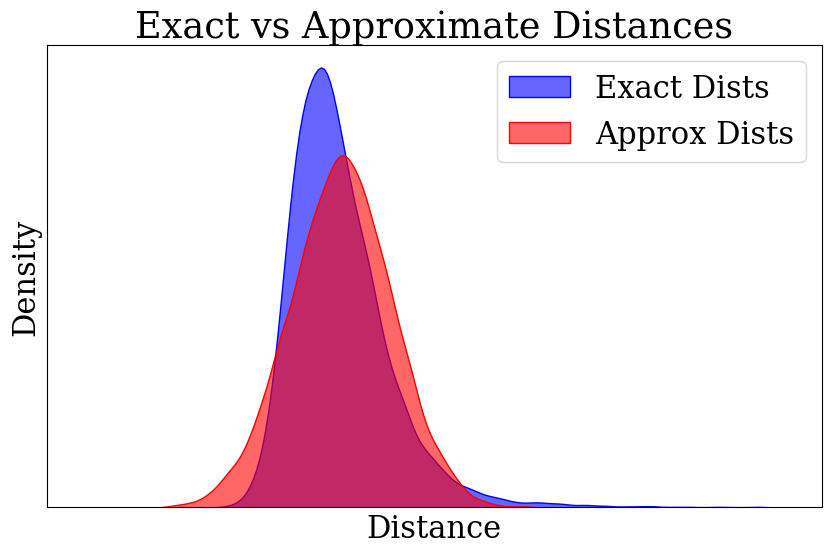

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'serif'  # You can replace 'serif' with 'sans-serif', 'monospace', etc.

# Flatten the matrices
exact_dists_flat = exact_dists_norm.flatten()
approx_dists_flat = approx_dists_norm.flatten()

# Generate random indices (e.g., 1000 indices)
sample_size = 10000
indices = np.random.choice(len(exact_dists_flat), sample_size, replace=False)

# Select corresponding samples from both matrices
exact_sample = exact_dists_flat[indices]
approx_sample = approx_dists_flat[indices]

# Plot smooth KDE plots with filled area
plt.figure(figsize=(10, 6))

# Plot for exact distances (fill the area with color)
sns.kdeplot(exact_sample, color='blue', label='Exact Dists', fill=True, alpha=0.6)

# Plot for approx distances (fill the area with color)
sns.kdeplot(approx_sample, color='red', label='Approx Dists', fill=True, alpha=0.6)

# Customize the plot
plt.title('Exact vs Approximate Distances')
plt.xlabel('Distance')
plt.ylabel('Density')
plt.legend()

# Remove x and y axis numbers
plt.xticks([])  # Remove x-axis ticks (numbers)
plt.yticks([])  # Remove y-axis ticks (numbers)

# Show the plot
plt.show()


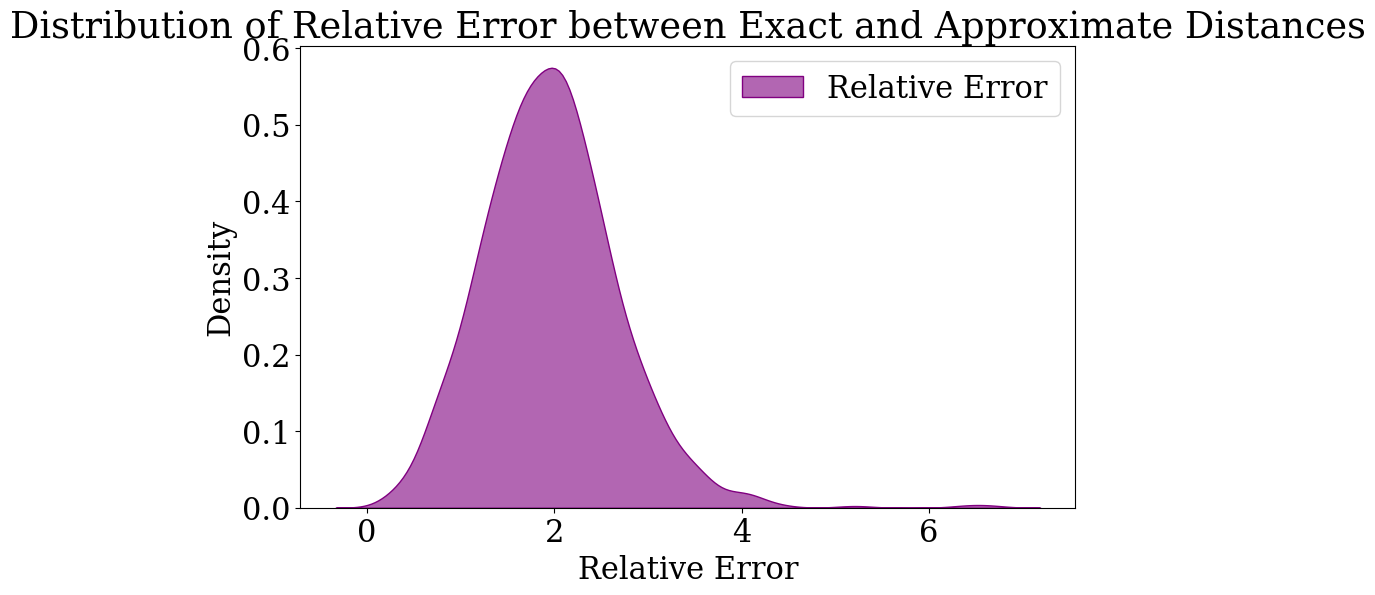

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'serif'  # You can replace 'serif' with 'sans-serif', 'monospace', etc.

# Flatten the relative error matrix for plotting
rel_error_flat = rel_error_matrix.flatten()

# Generate random indices (optional, if you want a sample size)
sample_size = 1000
indices = np.random.choice(len(rel_error_flat), sample_size, replace=False)

# Select corresponding samples from the relative error matrix
rel_error_sample = rel_error_flat[indices]

# Plot smooth KDE for the relative error distribution
plt.figure(figsize=(10, 6))

# Plot for the relative error (fill the area with color)
sns.kdeplot(rel_error_sample, color='purple', label='Relative Error', fill=True, alpha=0.6)

# Customize the plot
plt.title('Distribution of Relative Error between Exact and Approximate Distances')
plt.xlabel('Relative Error')
plt.ylabel('Density')
plt.legend()

# # Remove x and y axis numbers
# plt.xticks([])  # Remove x-axis ticks (numbers)
# plt.yticks([])  # Remove y-axis ticks (numbers)

# Show the plot
plt.show()


## NEW

In [ ]:
import numpy as np 
import faiss
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from numba import jit, prange
import threading
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs
from src.utils import append_or_create_csv
from src.utils import compute_distance_tables_threaded, compute_distance_tables_vectorized, adc_distances_batch_numba\
                    , compute_all_distances_batch, adc_distances_all_optimized, lsq_alpha_from_codes \
                    , lsq_dot_tables_vectorized, lsq_distances_batch_numba
  



In [2]:

# Dataset parameters
dataset_name = 'GIST'
sampling_method = 'random'
train_size_ratio = 0.1
k = 100  # Number of nearest neighbors

# PQ parameters
nbits = 8  # 2^nbits centroids per subquantizer
n_subquantizers = 8  # Number of subquantizers
ksub = 1 << nbits  # 256 centroids per subquantizer

print("Loading GIST dataset...")
# Loading the GIST dataset
db = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_base.fvecs'))
qr = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_query.fvecs'))

nb = db.shape[0]  # Number of database vectors
nq = qr.shape[0]  # Number of query vectors
dim = db.shape[1]  # Dimensionality of the vectors

print(f"Database shape: {db.shape}")
print(f"Query shape: {qr.shape}")
print(f"Dimension: {dim}")

# Ensure data is float32 for FAISS
db = db.astype(np.float32)
qr = qr.astype(np.float32)

Loading GIST dataset...
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_base.fvecs:(1000000, 960)
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_query.fvecs:(1000, 960)
Database shape: (1000000, 960)
Query shape: (1000, 960)
Dimension: 960


In [3]:

# Sample training data if specified
if sampling_method == 'random':
    train_size = int(nb * train_size_ratio)
    train_indices = np.random.choice(nb, train_size, replace=False)
    train_data = db[train_indices]
    print(f"Training on {train_size} vectors ({train_size_ratio:.1%} of database)")
else:
    train_data = db
    print("Training on full database")

# Setup Product Quantizer
print(f"\nSetting up Product Quantizer...")
print(f"Parameters: {n_subquantizers} subquantizers, {nbits} bits each")
print(f"Compression: {dim*4} bytes -> {n_subquantizers} bytes per vector")

pq = faiss.ProductQuantizer(dim, n_subquantizers, nbits)

# Train the PQ
print("Training Product Quantizer...")
start_time = time.time()
pq.train(train_data)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")


Training on 100000 vectors (10.0% of database)

Setting up Product Quantizer...
Parameters: 8 subquantizers, 8 bits each
Compression: 3840 bytes -> 8 bytes per vector
Training Product Quantizer...
Training completed in 3.09 seconds


In [4]:

# Encode database vectors
print("Encoding database vectors...")
start_time = time.time()
try:
    codes = pq.compute_codes(db)
except TypeError:
    codes = np.zeros((nb, pq.code_size), dtype='uint8')
    pq.compute_codes(db, codes)
encoding_time = time.time() - start_time
print(f"Encoding completed in {encoding_time:.2f} seconds")
print(f"Codes shape: {codes.shape}")



Encoding database vectors...
Encoding completed in 1.63 seconds
Codes shape: (1000000, 8)


In [5]:

# Compute distance tables with optimization
print("Computing distance tables (optimized)...")
start_time = time.time()

# Get centroids from trained PQ
centroids = faiss.vector_to_array(pq.centroids).reshape(n_subquantizers, ksub, dim // n_subquantizers)

# Choose computation method based on dataset size
if nq > 1000:
    print("Using multi-threaded computation...")
    dis_tables = compute_distance_tables_threaded(qr, centroids, n_subquantizers, ksub, dim)
else:
    print("Using vectorized computation...")
    dis_tables = compute_distance_tables_vectorized(qr, centroids, n_subquantizers, ksub, dim)

distance_table_time = time.time() - start_time
print(f"Distance tables computed in {distance_table_time:.2f} seconds")


Computing distance tables (optimized)...
Using vectorized computation...
Distance tables computed in 0.82 seconds


In [10]:
centroids.shape

(8, 256, 120)

In [6]:

sample_queries=1000
sample_db=10000

q_idx = np.random.choice(nq, min(sample_queries, nq), replace=False)
db_idx = np.random.choice(nb, min(sample_db, nb), replace=False)



qr_sample = qr[q_idx]
db_sample = db[db_idx]


# ADC distances for sampled subset
t0 = time.time()
adc_sample = adc_distances_batch_numba(
    dis_tables[q_idx], codes[db_idx], n_subquantizers
)
adc_time = time.time() - t0

print('adc time:', adc_time)

adc time: 0.9109292030334473


In [7]:
adc_sample

array([[1.89626, 0.53286, 2.05276, ..., 1.53721, 2.8926 , 0.70508],
       [1.65079, 1.93999, 1.06959, ..., 1.56104, 1.39172, 1.90865],
       [3.3059 , 3.15294, 3.11715, ..., 2.37373, 4.33861, 3.34166],
       ...,
       [3.18138, 0.9761 , 3.15882, ..., 2.59742, 3.70456, 1.67675],
       [2.58025, 3.75102, 2.59421, ..., 2.89085, 1.76298, 2.69879],
       [2.47715, 2.04375, 1.99339, ..., 2.09777, 1.62087, 1.74804]],
      dtype=float32)

In [91]:
q_idx.tofile('/data/cpanourg/2-hdvc/results/pq/q_idx.bin')
db_idx.tofile('/data/cpanourg/2-hdvc/results/pq/db_idx.bin')

In [8]:

# Exact distances with cdist
t0 = time.time()
exact_sample = cdist(qr_sample, db_sample, metric="sqeuclidean").astype(np.float32)
cdist_time = time.time() - t0


In [9]:
exact_sample 

array([[3.73094, 1.01565, 2.59927, ..., 1.97665, 3.63904, 1.04921],
       [3.92263, 2.21616, 1.7296 , ..., 2.18357, 2.26897, 2.34425],
       [5.51168, 3.83349, 3.81564, ..., 2.56168, 5.5392 , 3.86719],
       ...,
       [5.72353, 1.58469, 3.74801, ..., 3.14363, 4.4573 , 1.97257],
       [3.89202, 3.89039, 2.96071, ..., 4.04268, 2.55105, 2.74244],
       [4.87738, 2.51599, 2.53436, ..., 3.00248, 2.24608, 1.89064]],
      dtype=float32)

In [94]:
exact_sample.tofile('/data/cpanourg/2-hdvc/results/pq/exact_dists.bin')

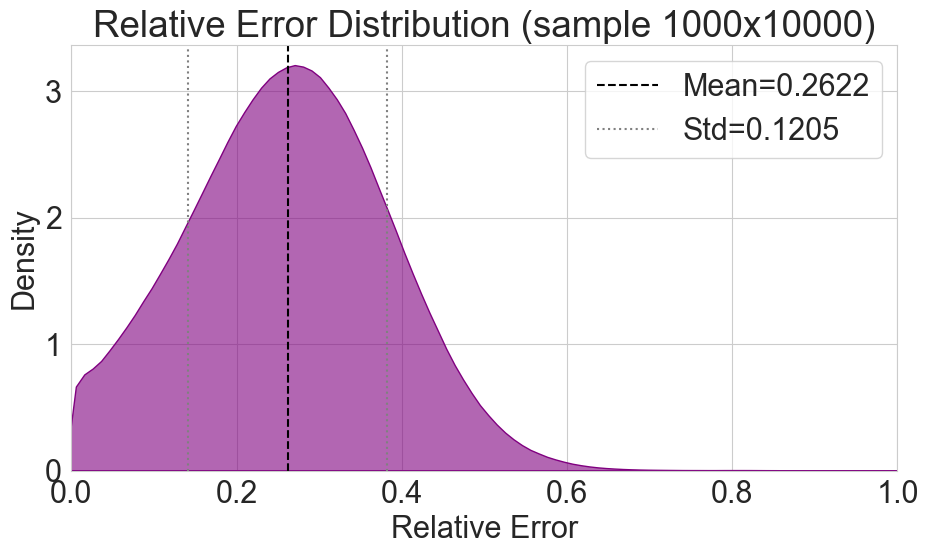

[cdist] sample 1000 queries x 10000 DB: 4.734s
Mean relative error=0.262224, Std=0.120461


In [95]:

plt.rcParams['font.family'] = 'serif'
sns.set_style("whitegrid")
# Relative errors
rel_error = np.abs(adc_sample - exact_sample) / (exact_sample + 1e-12)
rel_error.astype(np.float32).tofile('/data/cpanourg/2-hdvc/results/pq/rel_error.bin')
mean_rel, std_rel = rel_error.mean(), rel_error.std()

# Plot KDE of relative errors
rel_error_flat = rel_error.ravel()
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
sns.kdeplot(rel_error_flat, fill=True, color="purple", alpha=0.6)
plt.axvline(mean_rel, linestyle="--", color="black", label=f"Mean={mean_rel:.4f}")
plt.axvline(mean_rel-std_rel, linestyle=":", color="grey")
plt.axvline(mean_rel+std_rel, linestyle=":", color="grey", label=f"Std={std_rel:.4f}")
plt.title(f"Relative Error Distribution (sample {len(q_idx)}x{len(db_idx)})")
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(f"[cdist] sample {len(q_idx)} queries x {len(db_idx)} DB: {cdist_time:.3f}s")
print(f"Mean relative error={mean_rel:.6f}, Std={std_rel:.6f}")


In [100]:

summary = {
    "method": "PQ",
    "dataset": dataset_name,
    "nq": nq,
    "nb": nb,
    "nb_sample": len(db_idx),
    "dim": dim,
    "n_subquantizers": n_subquantizers,
    # "k": k,
    "train_ratio": train_size_ratio,
    "train_size": train_size,
    "train_time_s": float(train_time),
    "encoding_time_s": float(encoding_time),
    "distance_table_time_s": float(distance_table_time),
    "cdist_time_s": float(cdist_time),
    "adc_time_s": float(adc_time),
    "rel_error_mean": float(mean_rel),
    "rel_error_std": float(std_rel),

}

csv_path="/data/cpanourg/2-hdvc/results/adc_vs_exact_eval.csv"

need_header = not Path(csv_path).exists() or Path(csv_path).stat().st_size == 0
with open(csv_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary.keys()))
    if need_header:
        writer.writeheader()
    writer.writerow(summary)



In [101]:
import pandas as pd

pd.read_csv("/data/cpanourg/2-hdvc/results/adc_vs_exact_eval.csv").round(4)


,method,dataset,nq,nb,nb_sample,dim,n_subquantizers,train_ratio,train_size,train_time_s,encoding_time_s,distance_table_time_s,cdist_time_s,adc_time_s,rel_error_mean,rel_error_std
0,PQ,GIST,1000,1000000,10000,960,8,0.1,100000,2.3651,1.6212,0.8034,4.7344,0.0201,0.2622,0.1205
